<a href="https://colab.research.google.com/github/snazrei/DSA210-Project/blob/main/analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import pandas as pd
import numpy as np
import ast

# Load data
movies = pd.read_csv("/content/tmdb_movies.csv.csv")
netflix = pd.read_csv("/content/netflix_titles.csv.csv")

print("TMDb shape:", movies.shape)
print("Netflix shape:", netflix.shape)

TMDb shape: (4803, 20)
Netflix shape: (8807, 12)


In [9]:
# Keep only relevant columns
movies = movies[['title', 'budget', 'revenue', 'genres',
                 'release_date', 'vote_average', 'vote_count',
                 'popularity', 'runtime', 'original_language']]

# Replace 0 with NaN (0 means data is missing)
movies['budget'] = movies['budget'].replace(0, np.nan)
movies['revenue'] = movies['revenue'].replace(0, np.nan)

# Drop rows where both budget and revenue are missing
movies = movies.dropna(subset=['budget', 'revenue'])

# Parse dates
movies['release_date'] = pd.to_datetime(movies['release_date'], errors='coerce')
movies['release_year']  = movies['release_date'].dt.year
movies['release_month'] = movies['release_date'].dt.month
movies['decade'] = (movies['release_year'] // 10 * 10).astype('Int64')

# Create new features
movies['profit']  = movies['revenue'] - movies['budget']
movies['roi']     = movies['profit'] / movies['budget']
movies['success'] = (movies['profit'] > 0).astype(int)

# Parse genres from JSON string
def extract_genres(genre_str):
    try:
        genres = ast.literal_eval(genre_str)
        return [g['name'] for g in genres]
    except:
        return []

movies['genres_list']   = movies['genres'].apply(extract_genres)
movies['primary_genre'] = movies['genres_list'].apply(
    lambda x: x[0] if len(x) > 0 else 'Unknown'
)

# Prepare Netflix data (movies only)
netflix_movies = netflix[netflix['type'] == 'Movie'][['title']].copy()
netflix_movies['on_netflix'] = 1

# Merge
df = movies.merge(netflix_movies, on='title', how='left')
df['on_netflix'] = df['on_netflix'].fillna(0).astype(int)

# Final check
print("Cleaned dataset shape:", df.shape)
print("On Netflix:", df['on_netflix'].sum(), "movies matched")
print(df[['title', 'budget', 'revenue', 'profit', 'primary_genre', 'release_year', 'on_netflix']].head())


Cleaned dataset shape: (3229, 19)
On Netflix: 594 movies matched
                                      title       budget       revenue  \
0                                    Avatar  237000000.0  2.787965e+09   
1  Pirates of the Caribbean: At World's End  300000000.0  9.610000e+08   
2                                   Spectre  245000000.0  8.806746e+08   
3                     The Dark Knight Rises  250000000.0  1.084939e+09   
4                               John Carter  260000000.0  2.841391e+08   

         profit primary_genre  release_year  on_netflix  
0  2.550965e+09        Action          2009           0  
1  6.610000e+08     Adventure          2007           0  
2  6.356746e+08        Action          2015           0  
3  8.349391e+08        Action          2012           0  
4  2.413910e+07        Action          2012           1  


             budget       revenue        profit  vote_average           roi
count  3.229000e+03  3.229000e+03  3.229000e+03   3229.000000  3.229000e+03
mean   4.065444e+07  1.212430e+08  8.058851e+07      6.309353  2.953822e+03
std    4.439674e+07  1.863029e+08  1.581479e+08      0.873891  1.506101e+05
min    1.000000e+00  5.000000e+00 -1.657101e+08      0.000000 -9.999995e-01
25%    1.050000e+07  1.700000e+07  2.113940e+05      5.800000  2.246328e-02
50%    2.500000e+07  5.518472e+07  2.616557e+07      6.300000  1.300366e+00
75%    5.500000e+07  1.462920e+08  9.748982e+07      6.900000  3.420822e+00
max    3.800000e+08  2.787965e+09  2.550965e+09      8.500000  8.499999e+06


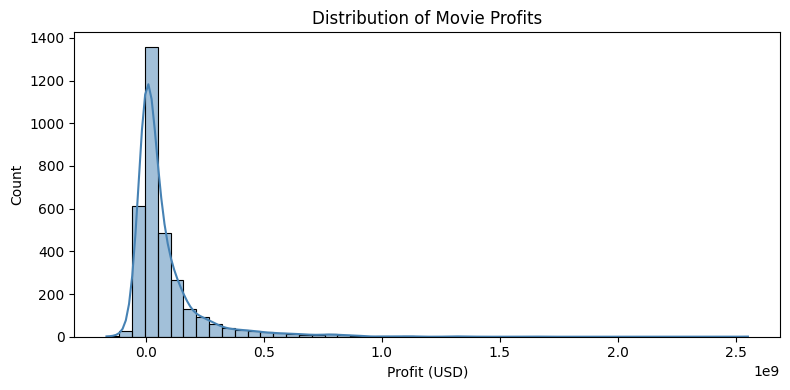

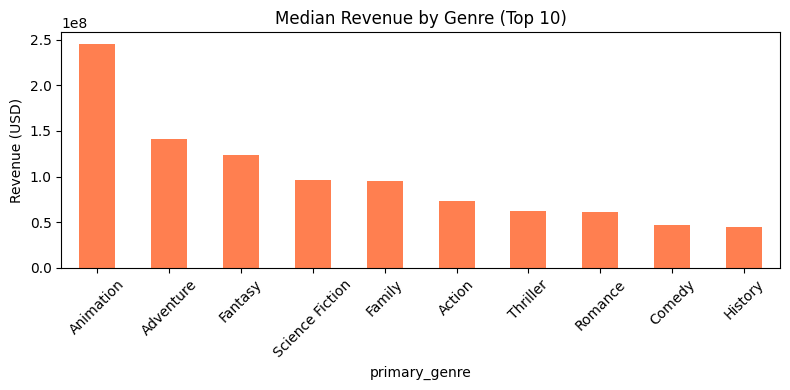

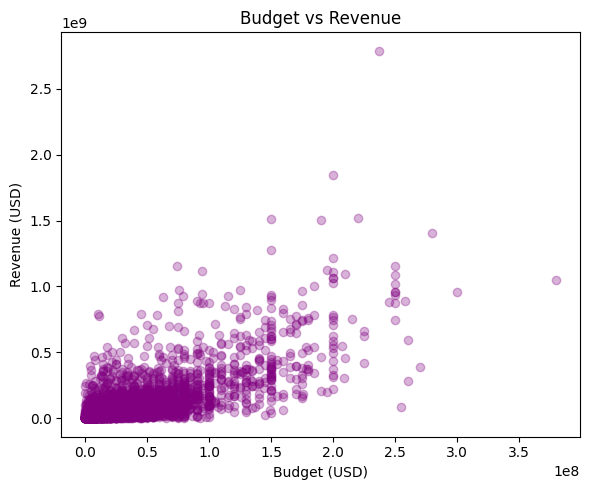

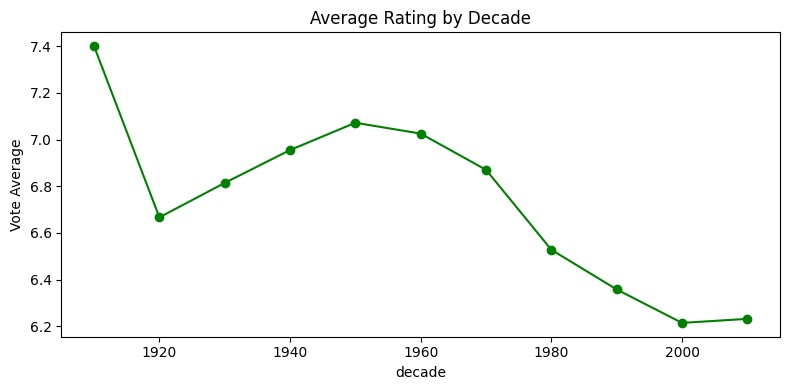

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns

# ── 1. Basic stats ────────────────────────────────────────────────────────────
print(df[['budget', 'revenue', 'profit', 'vote_average', 'roi']].describe())

# ── 2. Distribution of profits ────────────────────────────────────────────────
plt.figure(figsize=(8,4))
sns.histplot(df['profit'], bins=50, kde=True, color='steelblue')
plt.title('Distribution of Movie Profits')
plt.xlabel('Profit (USD)')
plt.tight_layout()
plt.show()

# ── 3. Revenue by genre ───────────────────────────────────────────────────────
genre_revenue = df.groupby('primary_genre')['revenue'].median().sort_values(ascending=False).head(10)
plt.figure(figsize=(8,4))
genre_revenue.plot(kind='bar', color='coral')
plt.title('Median Revenue by Genre (Top 10)')
plt.ylabel('Revenue (USD)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ── 4. Budget vs Revenue scatter ──────────────────────────────────────────────
plt.figure(figsize=(6,5))
plt.scatter(df['budget'], df['revenue'], alpha=0.3, color='purple')
plt.title('Budget vs Revenue')
plt.xlabel('Budget (USD)')
plt.ylabel('Revenue (USD)')
plt.tight_layout()
plt.show()

# ── 5. Average rating by decade ───────────────────────────────────────────────
decade_rating = df.groupby('decade')['vote_average'].mean()
plt.figure(figsize=(8,4))
decade_rating.plot(kind='line', marker='o', color='green')
plt.title('Average Rating by Decade')
plt.ylabel('Vote Average')
plt.tight_layout()
plt.show()


In [12]:
from scipy import stats

# ── Hypothesis 1: Budget vs Revenue correlation ───────────────────────────────
corr, p1 = stats.pearsonr(df['budget'], df['revenue'])
print("=== H1: Budget vs Revenue ===")
print(f"Pearson correlation: {corr:.3f}, p-value: {p1:.4f}")
if p1 < 0.05:
    print("✅ Significant positive correlation between budget and revenue\n")

# ── Hypothesis 2: Do some genres earn more revenue? ───────────────────────────
print("=== H2: Revenue differences across genres ===")
top_genres = ['Action', 'Comedy', 'Drama', 'Animation', 'Adventure']
groups = [df[df['primary_genre'] == g]['revenue'].dropna() for g in top_genres]
f_stat, p2 = stats.f_oneway(*groups)
print(f"ANOVA F-statistic: {f_stat:.3f}, p-value: {p2:.4f}")
if p2 < 0.05:
    print("✅ Significant revenue differences exist across genres\n")

# ── Hypothesis 3: Do recent movies get higher ratings? ────────────────────────
print("=== H3: Recent vs Older movies ratings ===")
recent = df[df['release_year'] >= 2000]['vote_average'].dropna()
older  = df[df['release_year'] <  2000]['vote_average'].dropna()
t_stat, p3 = stats.ttest_ind(recent, older)
print(f"T-statistic: {t_stat:.3f}, p-value: {p3:.4f}")
print(f"Recent movies avg rating: {recent.mean():.2f}")
print(f"Older movies avg rating:  {older.mean():.2f}")
if p3 < 0.05:
    print("✅ Significant difference in ratings between recent and older movies")
else:
    print("❌ No significant difference found")


=== H1: Budget vs Revenue ===
Pearson correlation: 0.705, p-value: 0.0000
✅ Significant positive correlation between budget and revenue

=== H2: Revenue differences across genres ===
ANOVA F-statistic: 81.217, p-value: 0.0000
✅ Significant revenue differences exist across genres

=== H3: Recent vs Older movies ratings ===
T-statistic: -8.943, p-value: 0.0000
Recent movies avg rating: 6.22
Older movies avg rating:  6.52
✅ Significant difference in ratings between recent and older movies
